Cylinder Flow (Steady) DEMO code

This notebook demonstrates solving steady-state Cavity Flow with the same setup as https://www.comsol.com/blogs/how-to-solve-a-classic-cfd-benchmark-the-lid-driven-cavity-problem.

In [1]:
import deepflow as df
print("Deepflow is runned on:", df.device) # to change to cpu use df.device = 'cpu'
df.manual_seed(69) # for reproducibility

Deepflow is runned on: cuda


## 1. Define Geometry Domain
Set up the computational domain: a rectangle with a circular obstacle (cylinder). This defines the area for simulation.

In [2]:
rectangle = df.geometry.rectangle([0, 1], [0, 1])

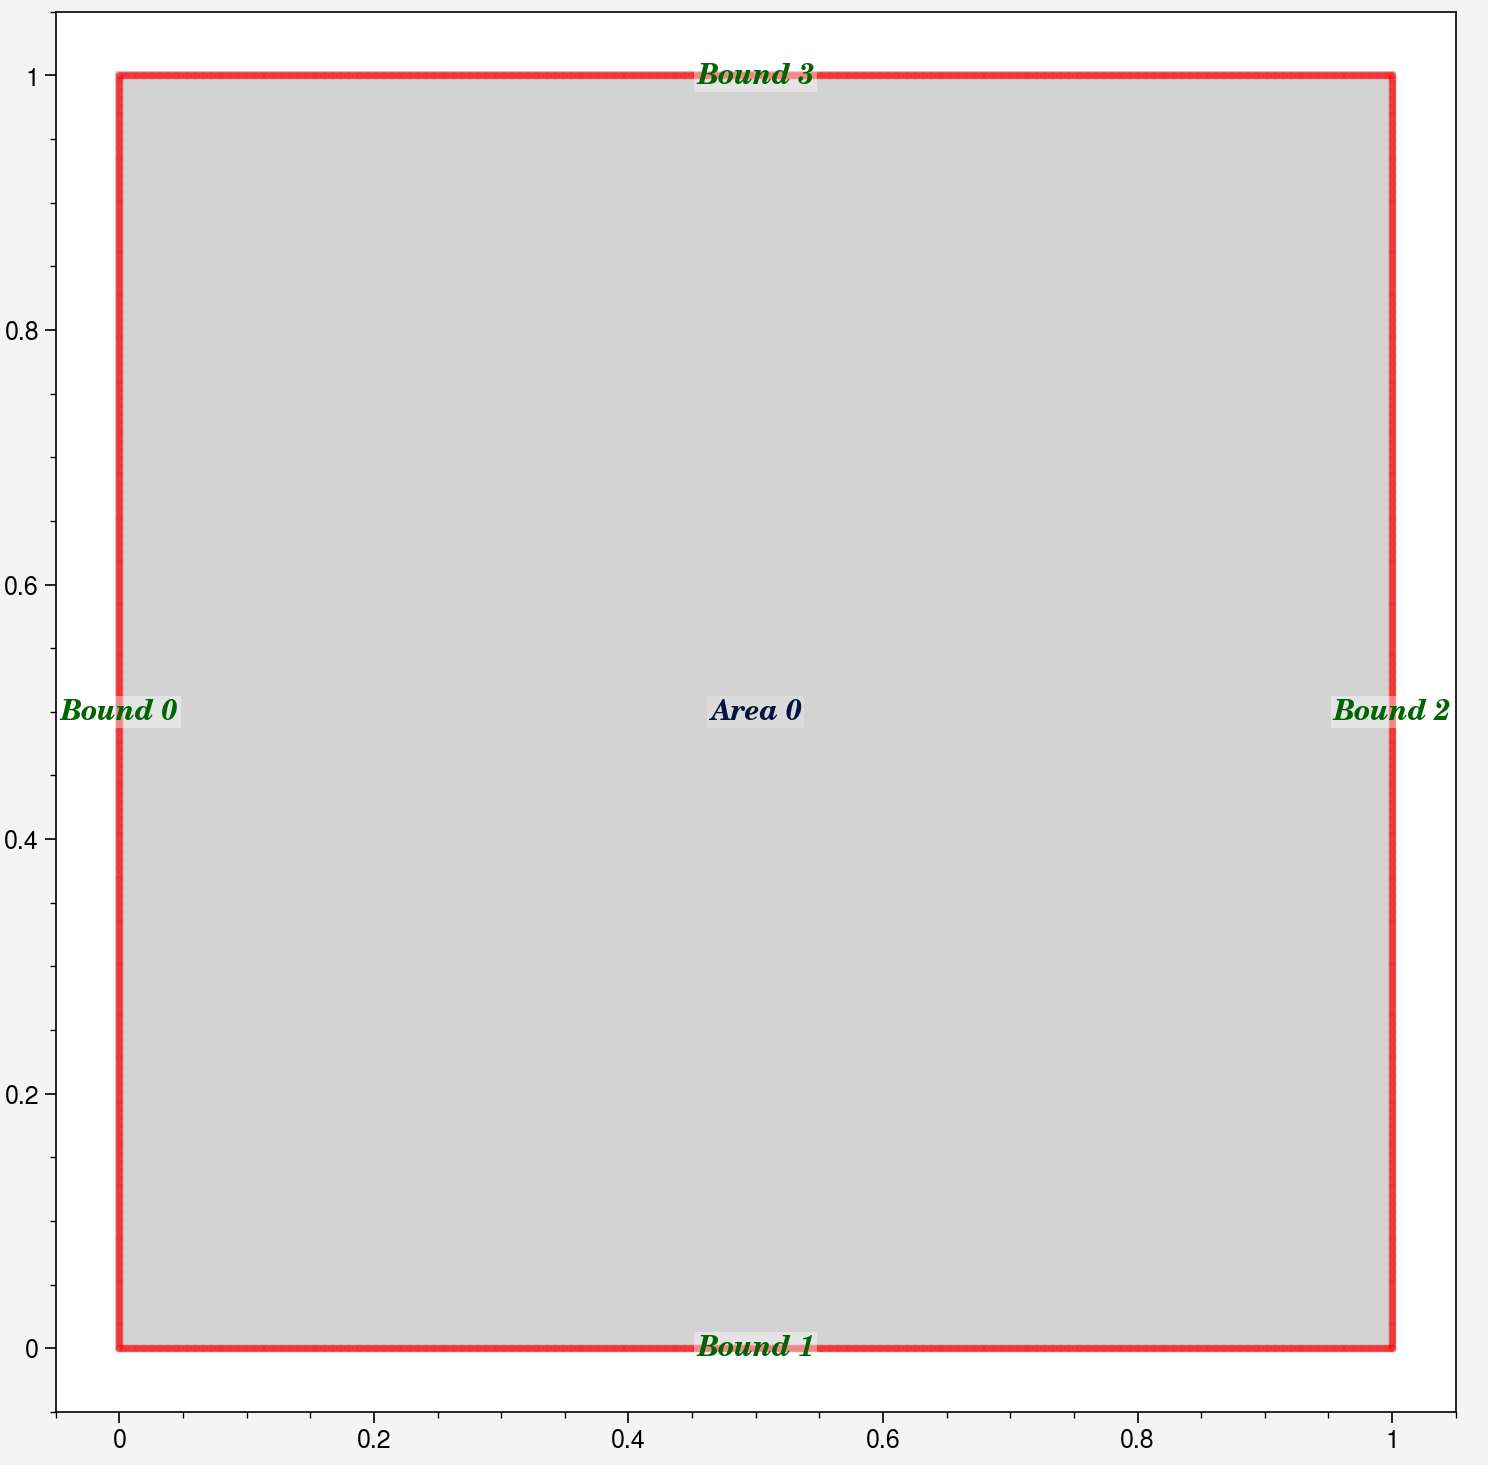

In [3]:
domain = df.domain(rectangle)
domain.show_setup()

## 2. Define Physics
Define the Navier-Stokes equations for fluid flow and apply boundary conditions (e.g., no-slip walls, inlet velocity).

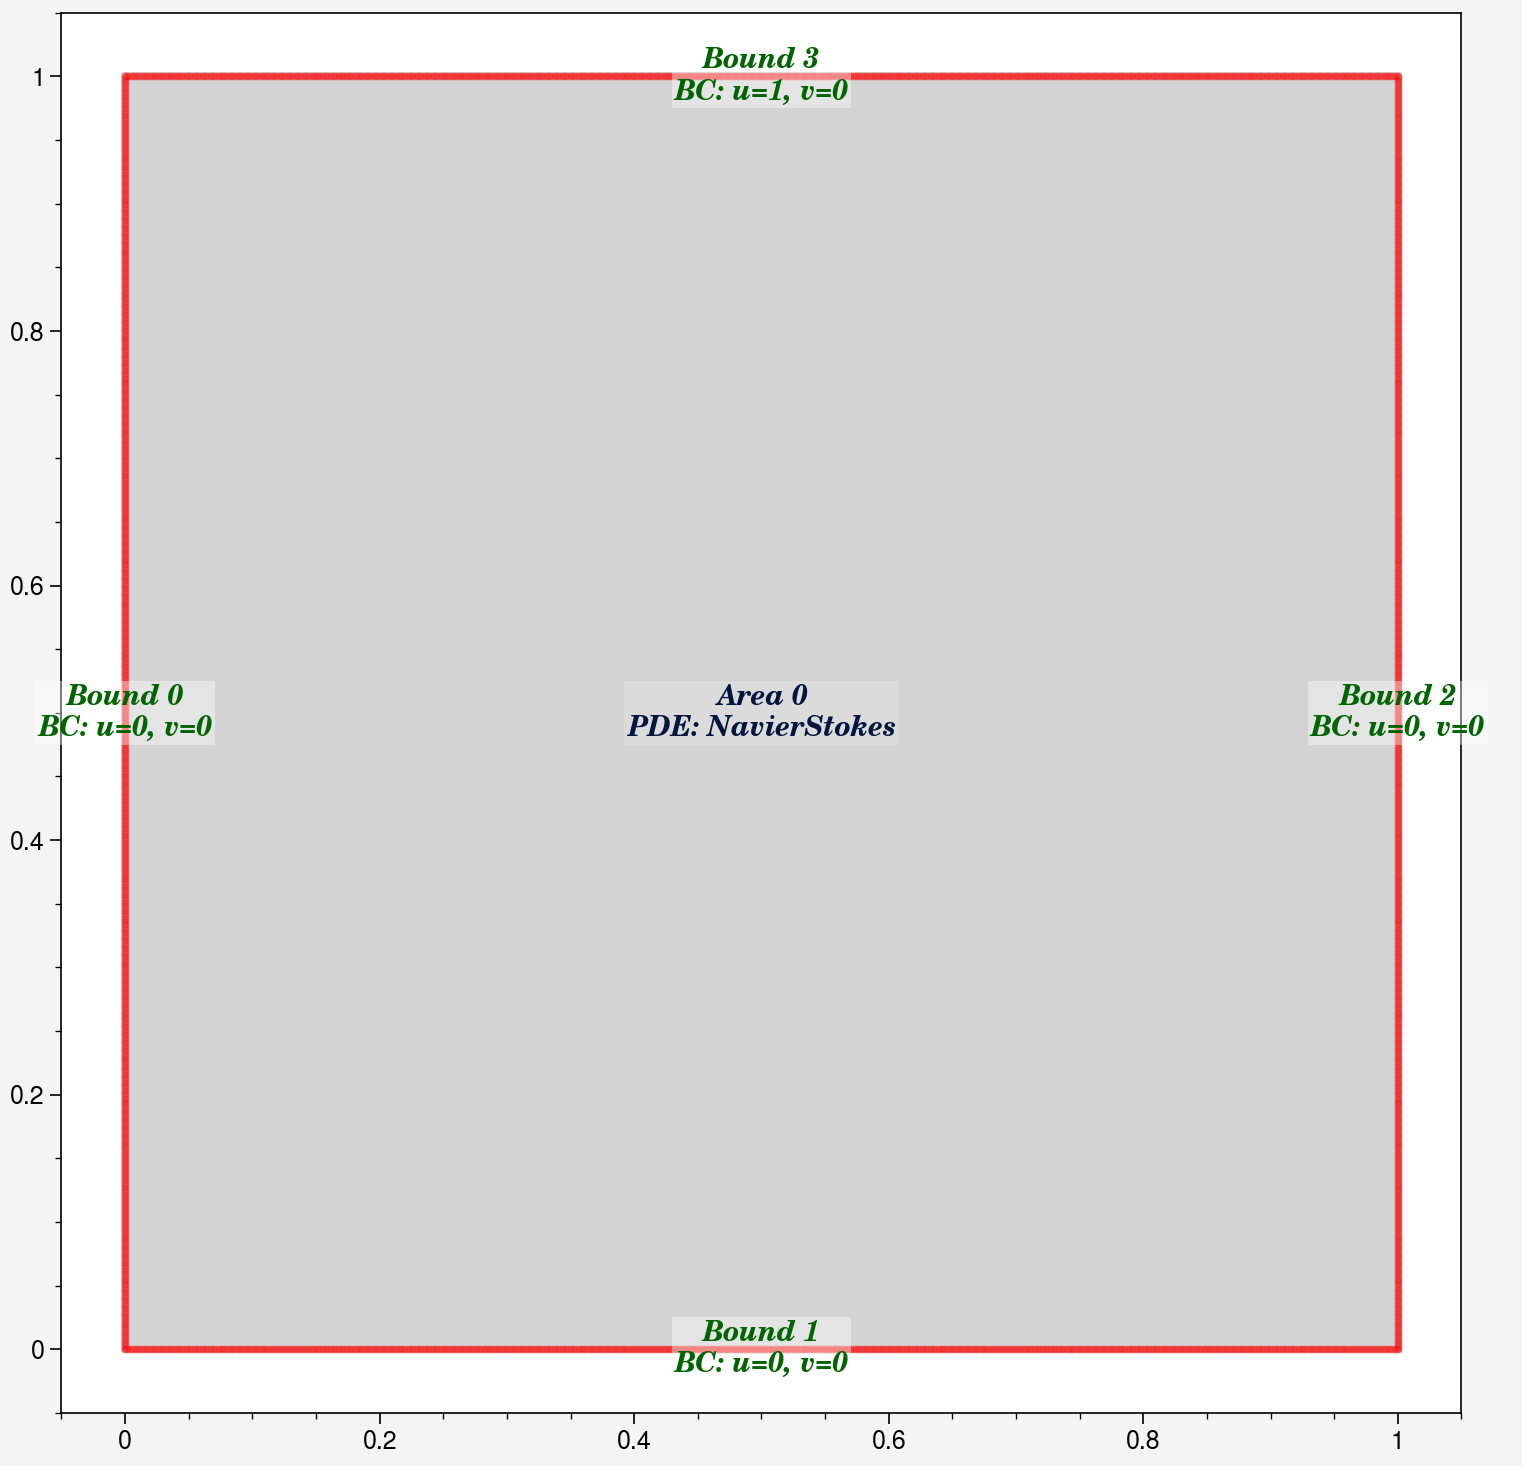

In [4]:
domain.bound_list[0].define_bc({'u': 0,'v': 0})
domain.bound_list[1].define_bc({'u': 0,'v': 0})
domain.bound_list[2].define_bc({'u': 0,'v': 0})
domain.bound_list[3].define_bc({'u': 1, 'v': 0})
domain.area_list[0].define_pde(df.NavierStokes(U=0.0001, L=1, mu=0.001, rho=1000))
domain.show_setup()


Sample initial points for training.

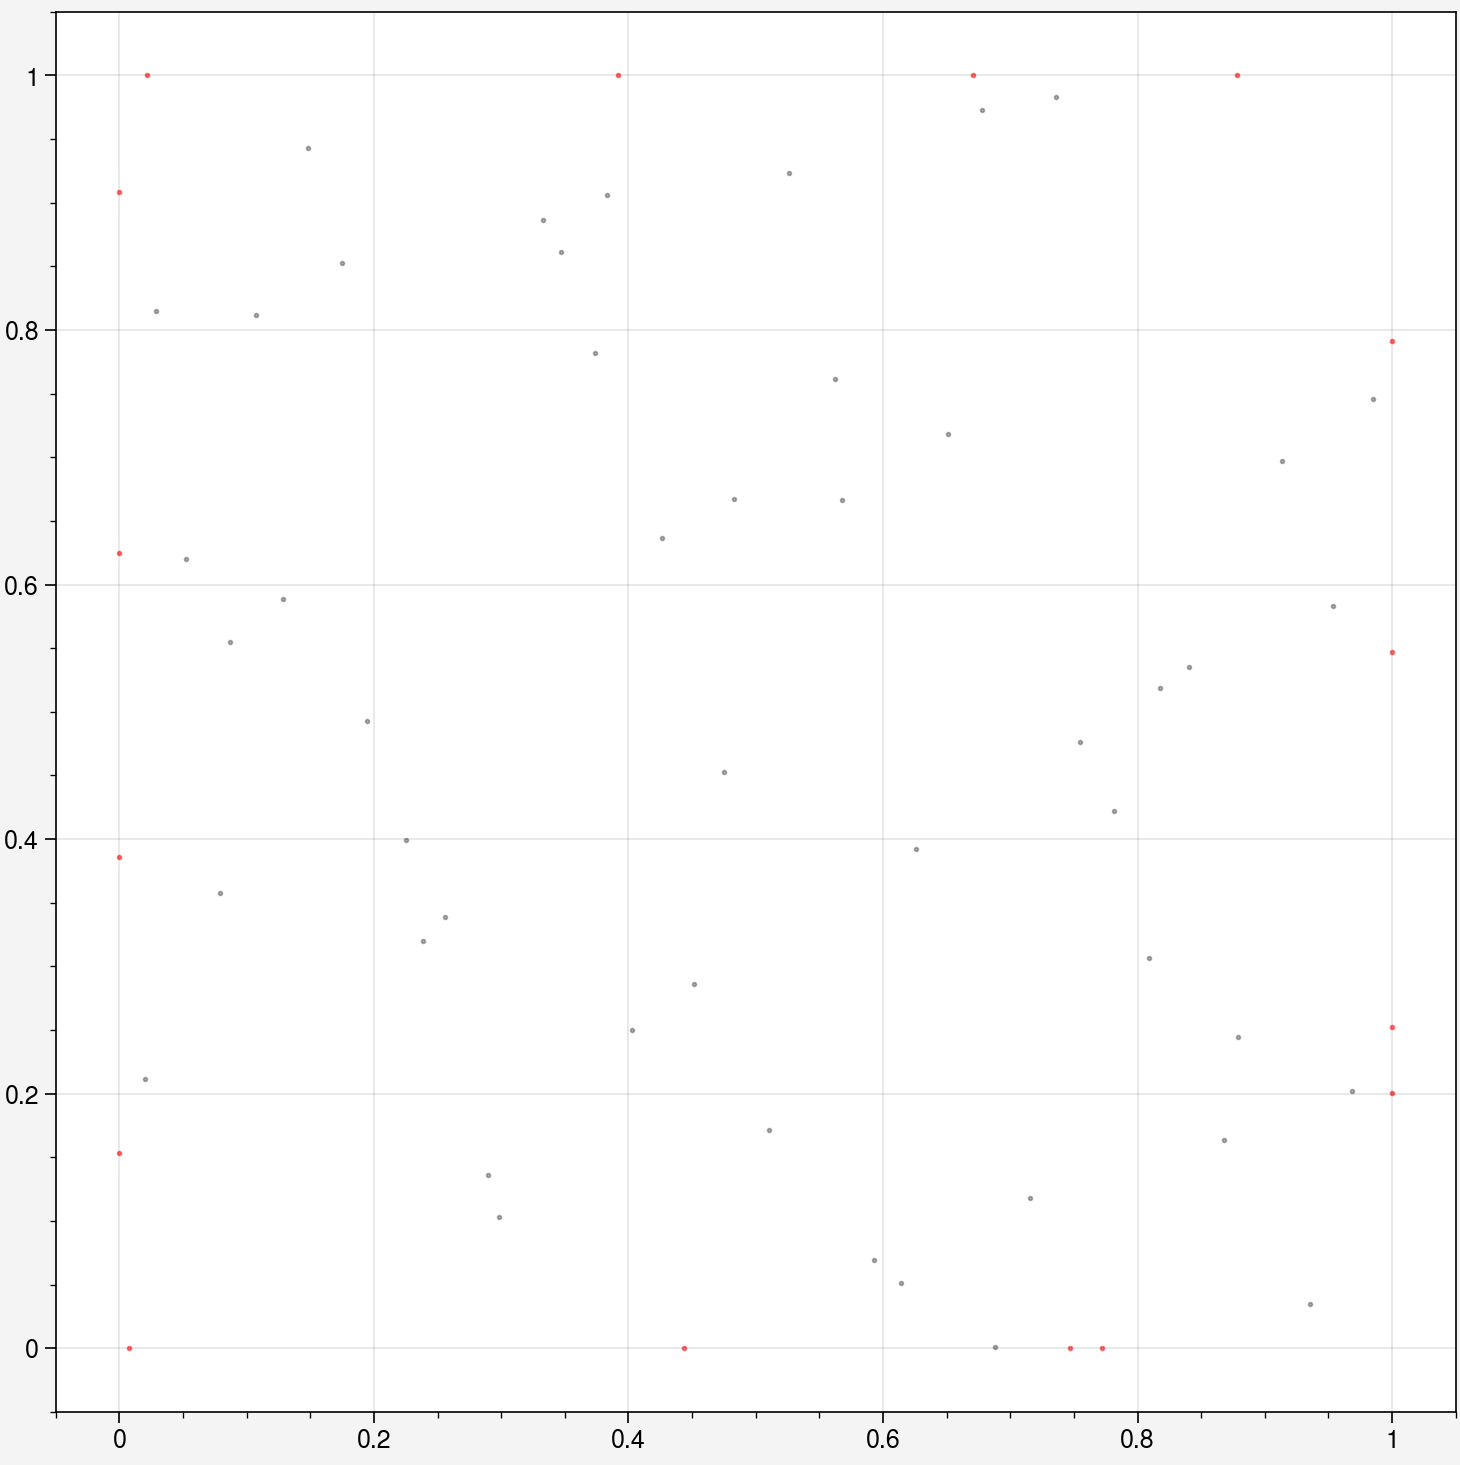

In [5]:
domain.sampling_lhs(bound_sampling_res=[4, 4, 4, 4], area_sampling_res=[48])
domain.show_coordinates(display_physics=False)

## 3. Train the PINN model

Define how collocation points are sampled during training.

In [ ]:
def do_in_adam(epoch, model):
    if epoch % 100 == 0 and epoch > 0:
        domain.sampling_lhs(bound_sampling_res=[4, 4, 4, 4], area_sampling_res=[48])
    return
    if epoch % 100 == 0 and epoch > 0:
        domain.sampling_R3(bound_sampling_res=[1000, 1000, 1000, 1000], area_sampling_res=[2000])
        print(domain)
        
def do_in_lbfgs(epoch, model):
    return
    if epoch % 100 == 0 and epoch > 0:
        domain.sampling_R3(bound_sampling_res=[1000, 1000, 1000, 1000], area_sampling_res=[2000])
        print(domain)

Train the model using Adam for initial training (faster convergence).

In [7]:
model0 = df.QNN(input_vars=['x','y'], output_vars=['u','v','p'])

# Train the model
model1, model1best = model0.train_adam(
    learning_rate=0.004,
    epochs=2000,
    calc_loss=df.calc_loss_simple(domain),
    threshold_loss=0.005,
    do_between_epochs=do_in_adam)

Epoch: 1, total_loss: 0.91889, bc_loss: 0.91207, pde_loss: 0.00682
Epoch: 200, total_loss: 0.32900, bc_loss: 0.32367, pde_loss: 0.00533
Epoch: 400, total_loss: 0.19402, bc_loss: 0.18948, pde_loss: 0.00454
Epoch: 600, total_loss: 0.13723, bc_loss: 0.13151, pde_loss: 0.00572
Epoch: 800, total_loss: 0.10646, bc_loss: 0.09741, pde_loss: 0.00905
Epoch: 1000, total_loss: 0.07992, bc_loss: 0.06774, pde_loss: 0.01218
Epoch: 1200, total_loss: 0.06532, bc_loss: 0.05043, pde_loss: 0.01488
Training interrupted by user.


Refine the model using LBFGS for higher precision.

In [ ]:
# Train the model
model2 = model1best.train_lbfgs(
    calc_loss=df.calc_loss_simple(domain),
    epochs=350,
    threshold_loss=0.0001,
    do_between_epochs=do_in_lbfgs)

Epoch: 2001, total_loss: 0.10460, bc_loss: 0.08395, pde_loss: 0.02065
Epoch: 2051, total_loss: 0.07850, bc_loss: 0.06234, pde_loss: 0.01616
Epoch: 2101, total_loss: 0.07850, bc_loss: 0.06234, pde_loss: 0.01616
number of bound : ['0: 1174', '1: 1390', '2: 1147', '3: 1422', '4: 10']
number of area : ['0: 2712']
Epoch: 2151, total_loss: 0.11894, bc_loss: 0.09682, pde_loss: 0.02212
Epoch: 2201, total_loss: 0.11894, bc_loss: 0.09682, pde_loss: 0.02212
number of bound : ['0: 1307', '1: 1707', '2: 1267', '3: 1754', '4: 10']
number of area : ['0: 3320']
Epoch: 2251, total_loss: 0.14424, bc_loss: 0.11773, pde_loss: 0.02651
Epoch: 2301, total_loss: 0.14424, bc_loss: 0.11773, pde_loss: 0.02651
number of bound : ['0: 1426', '1: 1989', '2: 1367', '3: 2045', '4: 10']
number of area : ['0: 3875']
Epoch: 2350, total_loss: 0.16613, bc_loss: 0.13711, pde_loss: 0.02902


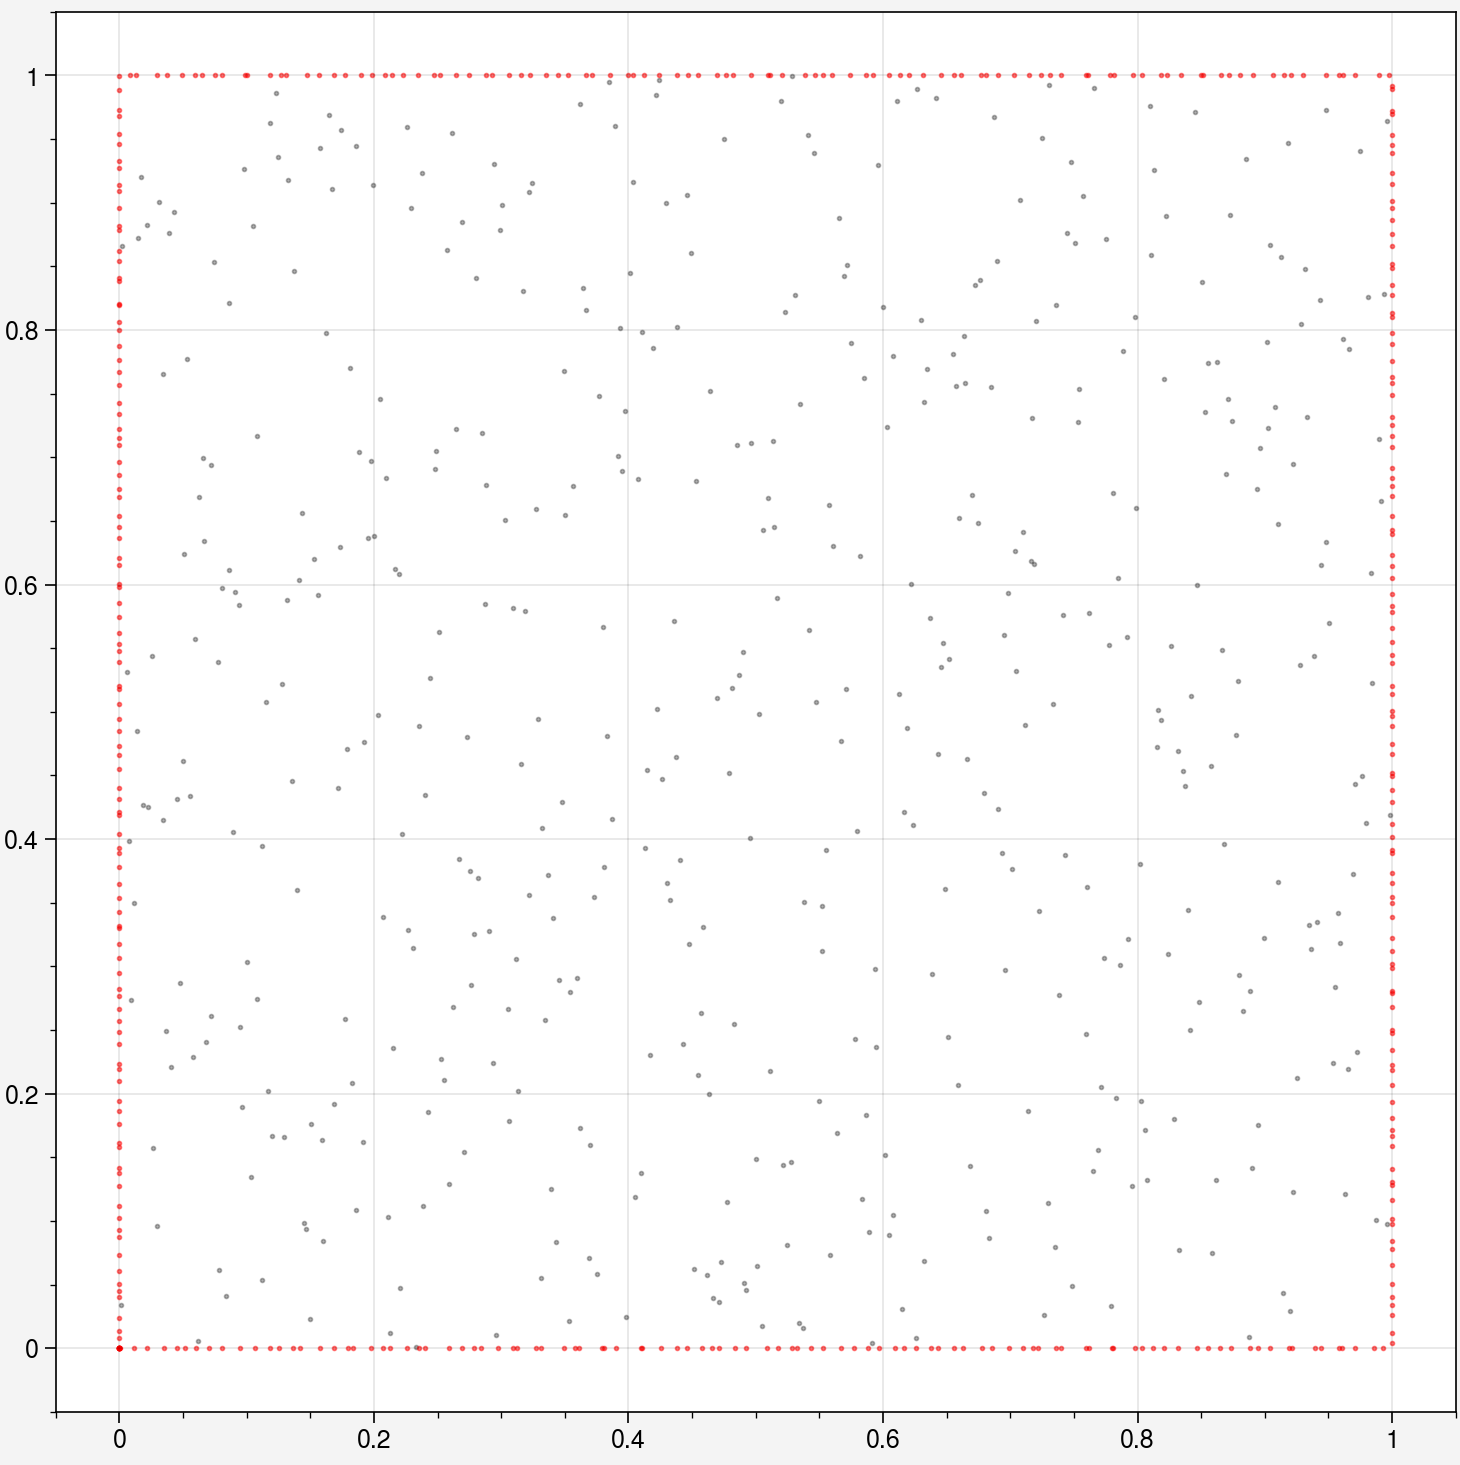

In [ ]:
domain.show_coordinates()

Save or Load the model for later use

In [8]:
model1.save_as_pickle("model.pkl")
model1 = df.load_from_pickle("model.pkl")

AttributeError: Can't pickle local object 'QNN._qnn_setup.<locals>._qnn_layer'

## 4. Visualization

### 4.1 Visualize area

In [9]:
df.Visualizer.refwidth_default = 4

In [10]:
# Create object for evaluation
area_eval = domain.area_list[0].evaluate(model1)
# Sampling uniform points
area_eval.sampling_area([200, 200])
# Show available data's key
print(area_eval)

Available data keys: ('u', 'v', 'p', 'pde_residual', 'x', 'y', 'u_x', 'u_y', 'v_x', 'v_y', 'p_x', 'p_y', 'continuity_residual', 'x_momentum_residual', 'y_momentum_residual', 'total_loss', 'bc_loss', 'pde_loss')


In [11]:
area_eval['v_mag'] = (area_eval['u']**2 + area_eval['v']**2)**0.5

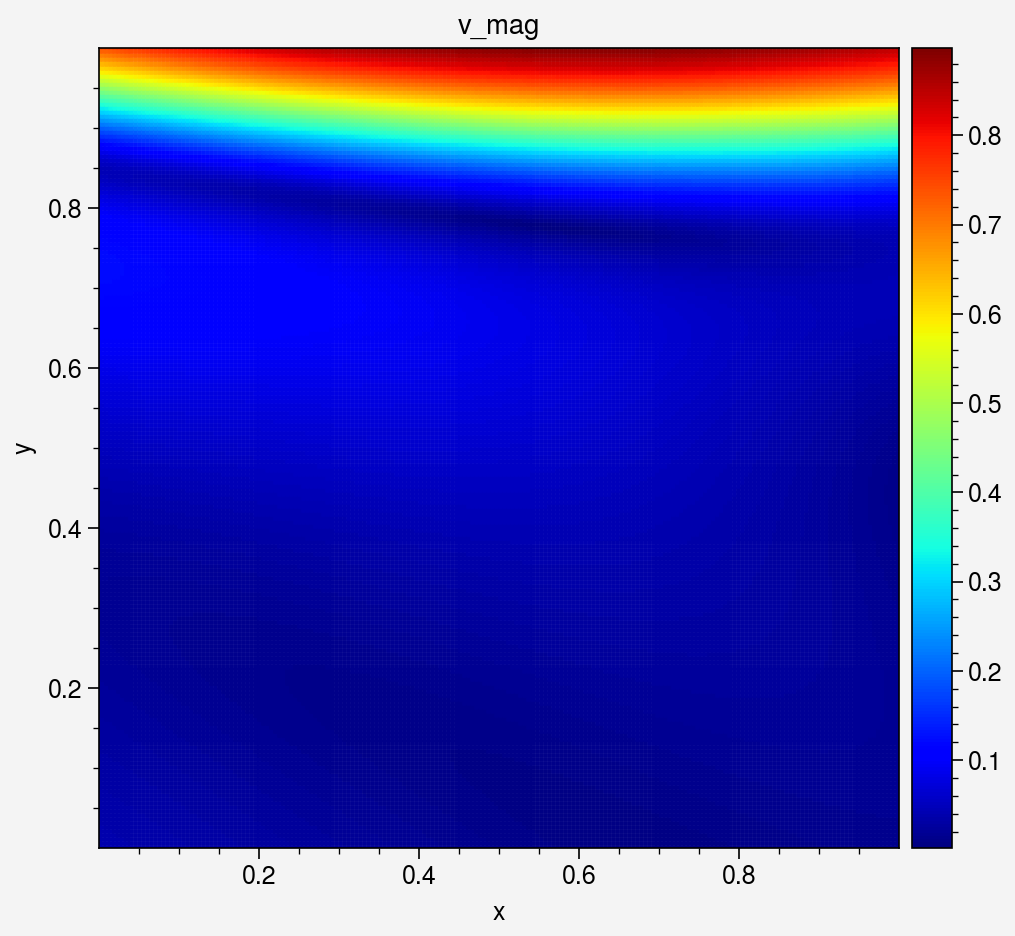

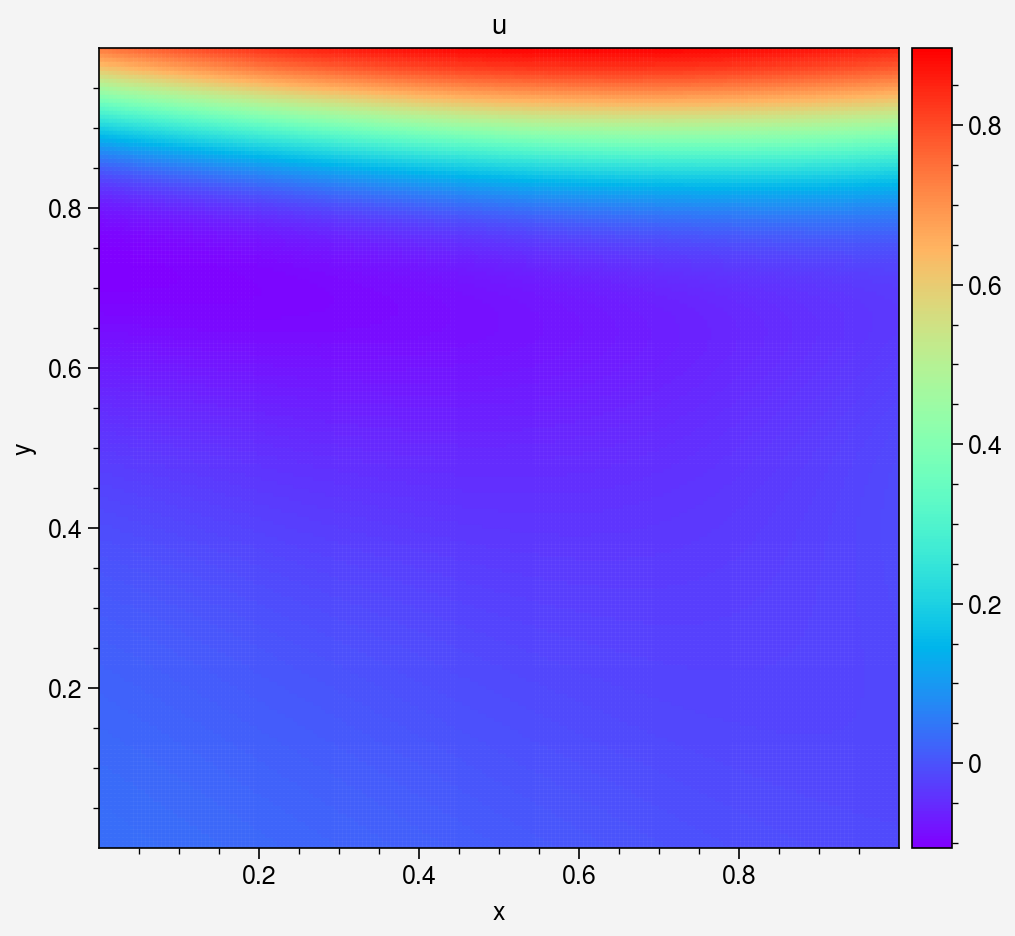

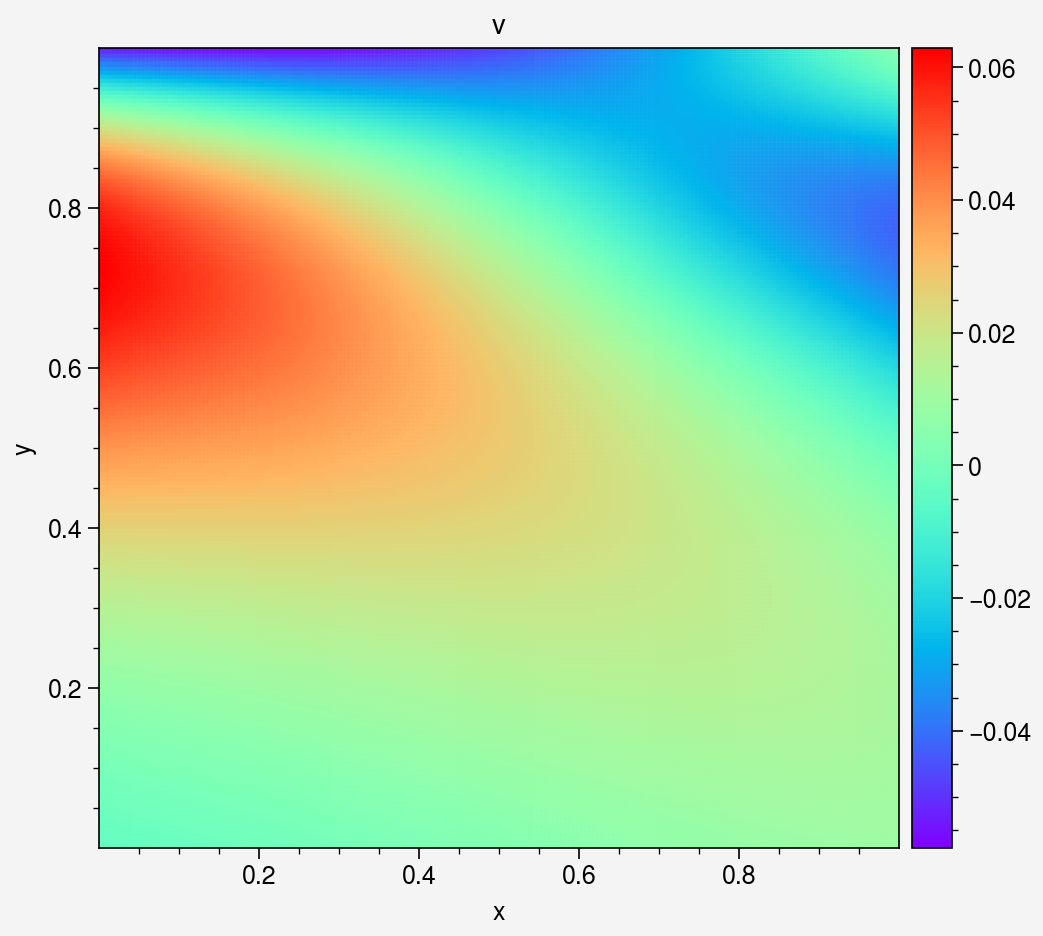

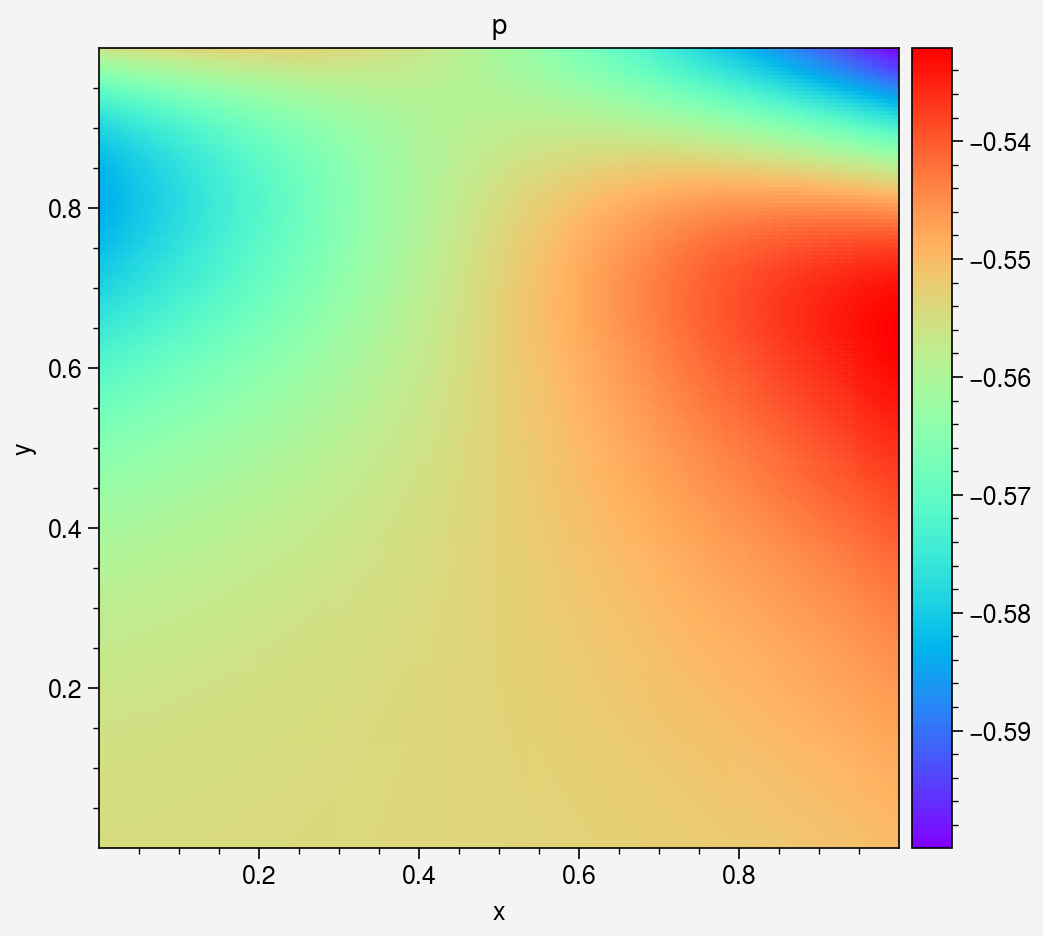

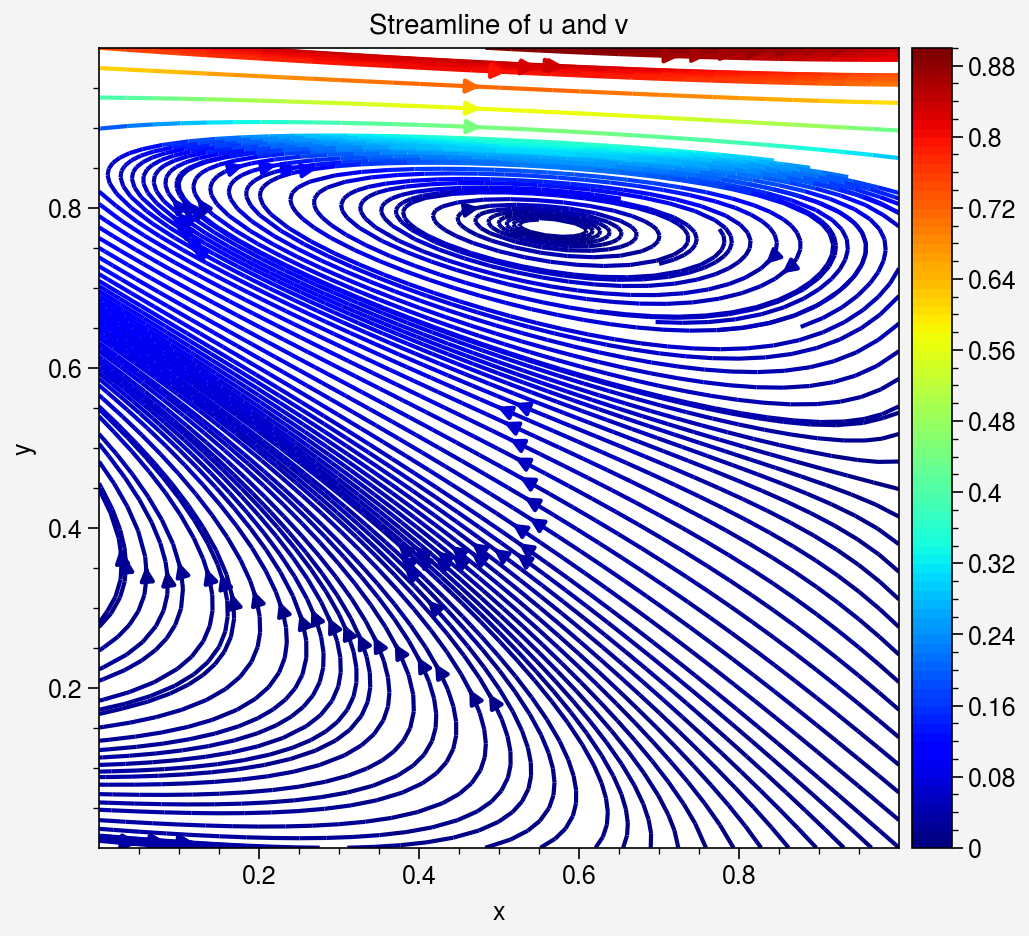

In [12]:
_ = area_eval.plot_color('v_mag', s=1.5, cmap='jet').savefig("colorplot_v_mag.png")
_ = area_eval.plot_color('u', s=1.5, cmap='rainbow')
_ = area_eval.plot_color('v', s=1.5, cmap='rainbow')
_ = area_eval.plot_color('p', s=1.5, cmap='rainbow')
_ = area_eval.plot_streamline('u', 'v', cmap = 'jet')

## 4.2 Visualize Neural Network data

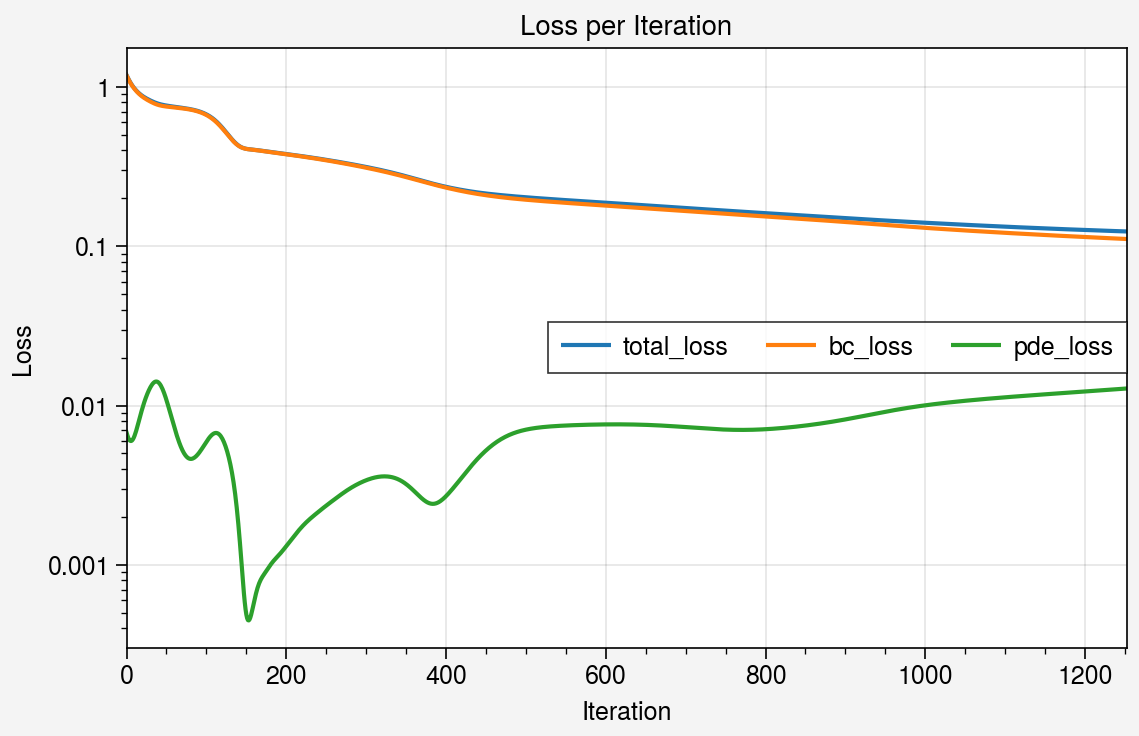

In [ ]:
_ = area_eval.plot_loss_curve(log_scale=True)

### 4.4 Export data

In [ ]:
# store the x,y,velocity_magnitude data
x_data = area_eval.data_dict['x']
y_data = area_eval.data_dict['y']
u_data = area_eval.data_dict['u']

#save as txt file
import numpy as np
array = np.column_stack((x_data, y_data, u_data))
np.savetxt('outlet_velocity.txt', array)